## Comprendre les préférences des voyageurs Airbnb : analyse des logements, des équipements et des facteurs de popularité.

## ⚙️ Statistique descriptive

### ➡️ Importation et aperçu de notre dataset

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("Data/airbnb_S4.csv")
data.head()

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


### ➡️ Manipulation et préparation

In [4]:
data.columns

Index(['Unnamed: 0', 'id', 'name', 'rating', 'reviews', 'host_name', 'host_id',
       'address', 'features', 'amenities', 'safety_rules', 'hourse_rules',
       'img_links', 'price', 'country', 'bathrooms', 'beds', 'guests',
       'toiles', 'bedrooms', 'studios', 'checkin', 'checkout'],
      dtype='str')

In [13]:
data = data.dropna(subset=["price", "rating", "reviews"])

# Conversion des prix

data["price"] = (
    data["price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)

# Conversion numérique des colonnes clés
for col in ["rating", "reviews", "bathrooms", "beds", "guests", "toiles", "bedrooms", "studios"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

### ➡️ Statistique descriptive ( fréquentation et popularité )

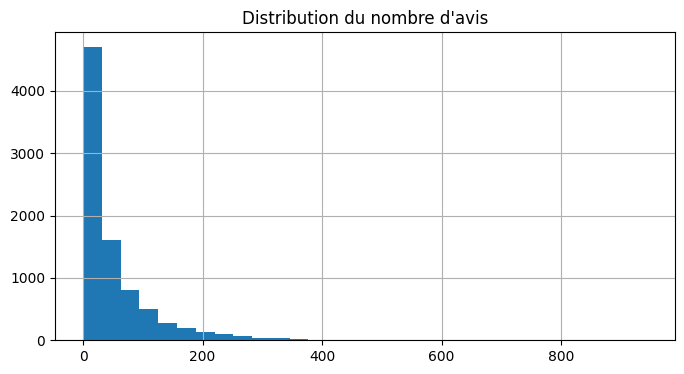

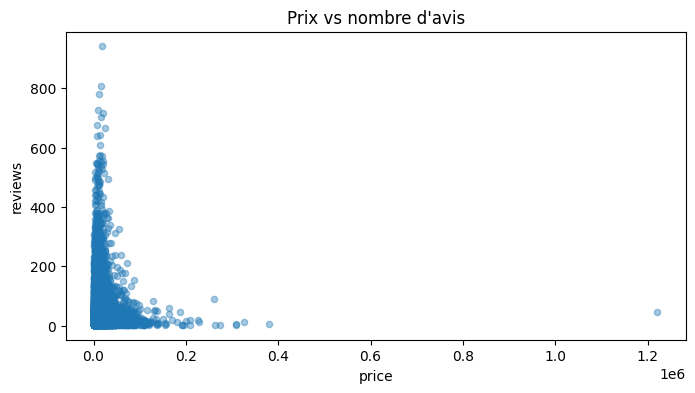

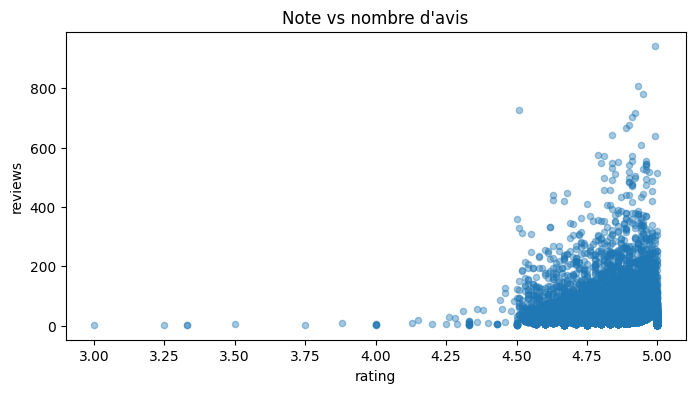

In [14]:
import matplotlib.pyplot as plt

# Distribution des avis
data["reviews"].hist(bins=30, figsize=(8,4))
plt.title("Distribution du nombre d'avis")
plt.show()

# Relation prix / avis
data.plot.scatter("price", "reviews", alpha=0.4, figsize=(8,4))
plt.title("Prix vs nombre d'avis")
plt.show()

# Relation rating / avis
data.plot.scatter("rating", "reviews", alpha=0.4, figsize=(8,4))
plt.title("Note vs nombre d'avis")
plt.show()


### ➡️ Types de logements et équipements

In [ ]:
data[["guests", "beds", "bedrooms", "bathrooms"]].describe()

,guests,beds,bedrooms,bathrooms
count,12805.000000,12805.000000,12805.000000,12805.000000
mean,5.213745,3.316751,2.136041,1.874424
std,3.808830,4.037791,2.359005,2.091399
min,1.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,1.000000
50%,4.000000,2.000000,1.000000,1.000000
75%,6.000000,4.000000,3.000000,2.000000
max,16.000000,98.000000,50.000000,50.000000


In [ ]:
# Seulement les équipements les plus fréquents
from collections import Counter

amenities_list = data["amenities"].dropna().apply(lambda x: x.split(","))
all_amenities = [item.strip() for sublist in amenities_list for item in sublist]

amenities_counts = Counter(all_amenities)
top_amenities = amenities_counts.most_common(20)

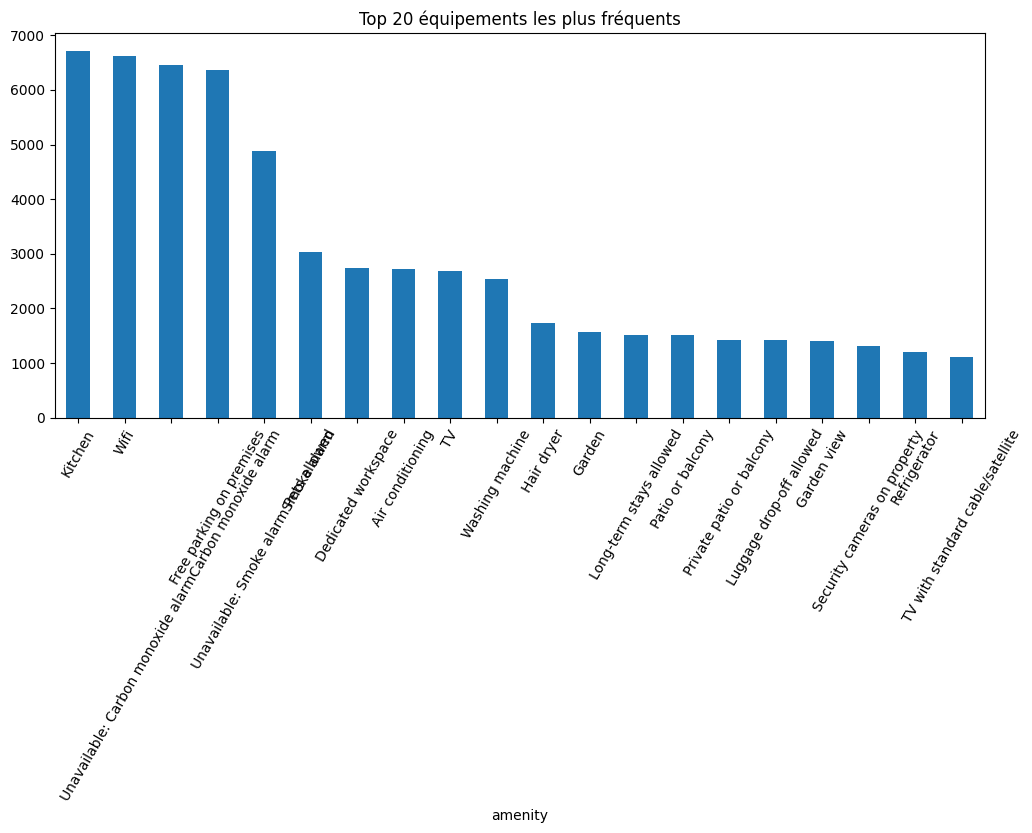

In [18]:
amen_data = pd.DataFrame(top_amenities, columns=["amenity", "count"])
amen_data.plot.bar(x="amenity", y="count", figsize=(12,5), legend=False)
plt.title("Top 20 équipements les plus fréquents")
plt.xticks(rotation=60)
plt.show()

### ➡️ Analyse géographique 

In [ ]:
# Prix moyen par pays
data.groupby("country")["price"].mean().sort_values(ascending=False)

country
 Honduras                273093.000000
 Bahamas                 116397.500000
Belize                   110603.000000
 Denmark                  54499.500000
 United Arab Emirates     44440.360000
                             ...      
 Kyrgyzstan                2061.333333
Cuba                       1817.000000
Jordan                     1812.000000
 Senegal                   1289.000000
Georgia                    1263.500000
Name: price, Length: 136, dtype: float64

In [ ]:
# Popularité par pays
data.groupby("country")["reviews"].mean().sort_values(ascending=False)

country
Iceland           329.000000
 Iceland          233.551724
 Liechtenstein    230.000000
 New Zealand      220.000000
 Costa Rica       183.750000
                     ...    
 St Martin          4.000000
 Kazakhstan         3.000000
 Honduras           3.000000
Egypt               3.000000
 Oman               3.000000
Name: reviews, Length: 136, dtype: float64

In [ ]:
# Notes moyennes par pays
data.groupby("country")["rating"].mean().sort_values(ascending=False)

country
 Honduras      5.00
 Myanmar       5.00
 Armenia       5.00
 Tunisia       5.00
 Kazakhstan    5.00
               ... 
 Uruguay       4.62
Taiwan         4.58
 Brunei        4.57
Jordan         4.50
 Bahamas       4.00
Name: rating, Length: 136, dtype: float64

### ➡️ Résumé

L’analyse descriptive du dataset Airbnb permet de dégager plusieurs enseignements clés sur la fréquentation et les préférences des voyageurs, sans recourir à des méthodes avancées comme les séries temporelles ou la statistique multivariée.

D’abord, l’étude des avis et des notes met en évidence une forte hétérogénéité dans la popularité des logements : certains hébergements concentrent un volume important d’avis, signe d’une forte fréquentation, tandis que d’autres restent très peu évalués. La relation entre prix et popularité montre que les logements les plus chers ne sont pas nécessairement les plus demandés, ce qui suggère que les voyageurs arbitrent entre budget, confort et localisation.

L’analyse de la typologie des logements révèle des tendances intéressantes : les hébergements destinés à plusieurs voyageurs (plus de lits, plus de chambres, plusieurs salles de bain) présentent des niveaux de prix plus élevés, mais pas toujours une meilleure note ou davantage d’avis. Cela indique que le confort structurel n’est pas le seul critère de choix pour les touristes.

L’étude des équipements met en lumière les préférences les plus marquées. Certains équipements — comme le Wi-Fi, la cuisine, l’espace de travail ou le parking — apparaissent très fréquemment, ce qui confirme leur importance dans la décision des voyageurs. D’autres équipements plus premium, comme la piscine ou le jacuzzi, sont moins répandus mais fortement associés à des prix plus élevés. L’analyse des 20 équipements les plus fréquents montre une diversité importante, même si la visualisation peut être légèrement décalée en raison du nombre de modalités, un phénomène normal lorsque les catégories sont nombreuses et textuelles.

Enfin, l’analyse géographique souligne des différences notables entre pays : certains affichent des prix moyens plus élevés, tandis que d’autres concentrent davantage d’avis ou de meilleures notes. Cela reflète des dynamiques locales de marché, des niveaux de demande différents et des attentes variées selon les destinations.

Dans l’ensemble, cette approche descriptive permet de mieux comprendre ce que recherchent les voyageurs Airbnb : un équilibre entre prix, confort, équipements essentiels et attractivité du logement. Elle met également en évidence les facteurs qui influencent la popularité d’un hébergement, offrant ainsi des pistes utiles pour les hôtes et les acteurs du secteur touristique.